In [9]:
import pandas as pd
import matplotlib.pyplot as plt

data= {
    'Employee': ['John','Priya','Ravi','Sneha','Kiran','Amit','Sara','Raj','Neha','Vijay'],
    'Department': ['Sales','Marketing','Sales','HR','Marketing','Sales','HR','Marketing','Sales','HR'],
    'Region': ['East','West','North','South','East','West','North','South','East','West'],
    'Sales': [5000,8000,6500,3000,9000,7200,2800,8500,6000,3500],
    'Salary': [45000,52000,48000,38000,55000,50000,36000,53000,46000,39000],
    'Rating': [4.2,4.8,4.5,3.8,4.9,4.6,3.7,4.8,4.3,3.9]
}
df = pd.DataFrame(data)
print (df)



  Employee Department Region  Sales  Salary  Rating
0     John      Sales   East   5000   45000     4.2
1    Priya  Marketing   West   8000   52000     4.8
2     Ravi      Sales  North   6500   48000     4.5
3    Sneha         HR  South   3000   38000     3.8
4    Kiran  Marketing   East   9000   55000     4.9
5     Amit      Sales   West   7200   50000     4.6
6     Sara         HR  North   2800   36000     3.7
7      Raj  Marketing  South   8500   53000     4.8
8     Neha      Sales   East   6000   46000     4.3
9    Vijay         HR   West   3500   39000     3.9


In [10]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nBasic Statistics:')
print(df.describe())
print('\nMissing values:')
print(df.isnull().sum())

Shape: (10, 6)
Columns: ['Employee', 'Department', 'Region', 'Sales', 'Salary', 'Rating']

Basic Statistics:
             Sales      Salary     Rating
count    10.000000     10.0000  10.000000
mean   5950.000000  46200.0000   4.350000
std    2295.042967   6663.3325   0.440328
min    2800.000000  36000.0000   3.700000
25%    3875.000000  40500.0000   3.975000
50%    6250.000000  47000.0000   4.400000
75%    7800.000000  51500.0000   4.750000
max    9000.000000  55000.0000   4.900000

Missing values:
Employee      0
Department    0
Region        0
Sales         0
Salary        0
Rating        0
dtype: int64


In [11]:
print('=== BUSINESS ANALYSIS ===')
print()

print('1. Total Sales by Department:')
print(df.groupby('Department')['Sales'].sum().sort_values(ascending=False))
print()

print('2. Average Salary by Department:')
print(df.groupby('Department')['Salary'].mean().sort_values(ascending=False))
print()

print('3. Top 3 Performing Employees:')
print(df.sort_values('Sales', ascending=False).head(3)[['Employee','Department','Sales','Rating']])
print()

print('4. Average Rating by Department:')
print(df.groupby('Department')['Rating'].mean().sort_values(ascending=False))
print()

print('5. Total Sales by Region:')
print(df.groupby('Region')['Sales'].sum().sort_values(ascending=False))

=== BUSINESS ANALYSIS ===

1. Total Sales by Department:
Department
Marketing    25500
Sales        24700
HR            9300
Name: Sales, dtype: int64

2. Average Salary by Department:
Department
Marketing    53333.333333
Sales        47250.000000
HR           37666.666667
Name: Salary, dtype: float64

3. Top 3 Performing Employees:
  Employee Department  Sales  Rating
4    Kiran  Marketing   9000     4.9
7      Raj  Marketing   8500     4.8
1    Priya  Marketing   8000     4.8

4. Average Rating by Department:
Department
Marketing    4.833333
Sales        4.400000
HR           3.800000
Name: Rating, dtype: float64

5. Total Sales by Region:
Region
East     20000
West     18700
South    11500
North     9300
Name: Sales, dtype: int64


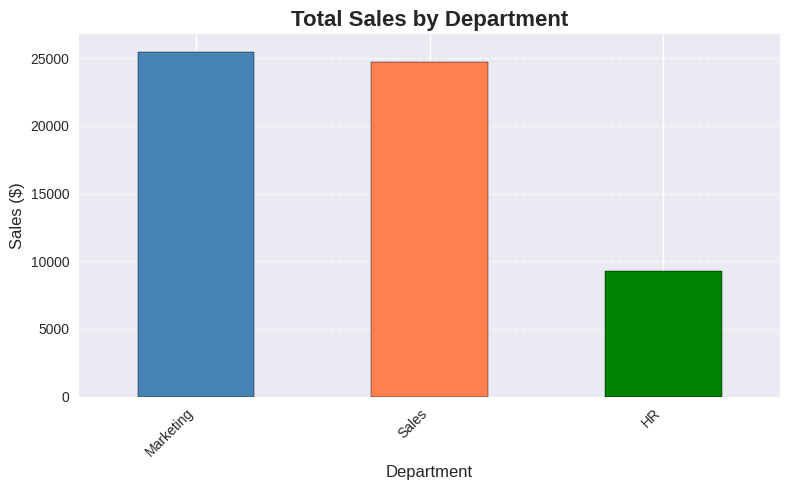

In [12]:
plt.style.use('seaborn-v0_8')

df.groupby('Department')['Sales'].sum().sort_values(ascending=False).plot(
    kind='bar',
    color=['steelblue','coral','green'],
    figsize=(8,5),
    edgecolor='black'
)
plt.title('Total Sales by Department', fontsize=16, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

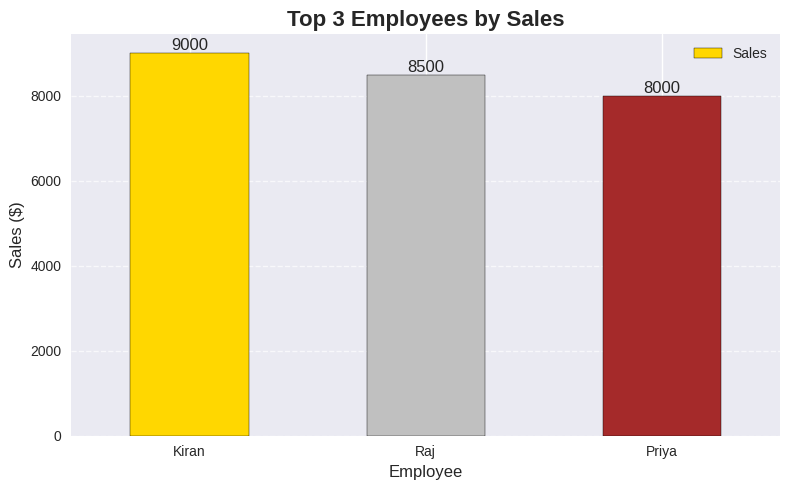

In [13]:
top3 = df.sort_values('Sales', ascending=False).head(3)

ax = top3.plot(
    kind='bar',
    x='Employee',
    y='Sales',
    color=['gold','silver','brown'],
    figsize=(8,5),
    edgecolor='black'
)
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        xy=(p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12
    )
plt.title('Top 3 Employees by Sales', fontsize=16, fontweight='bold')
plt.xlabel('Employee', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

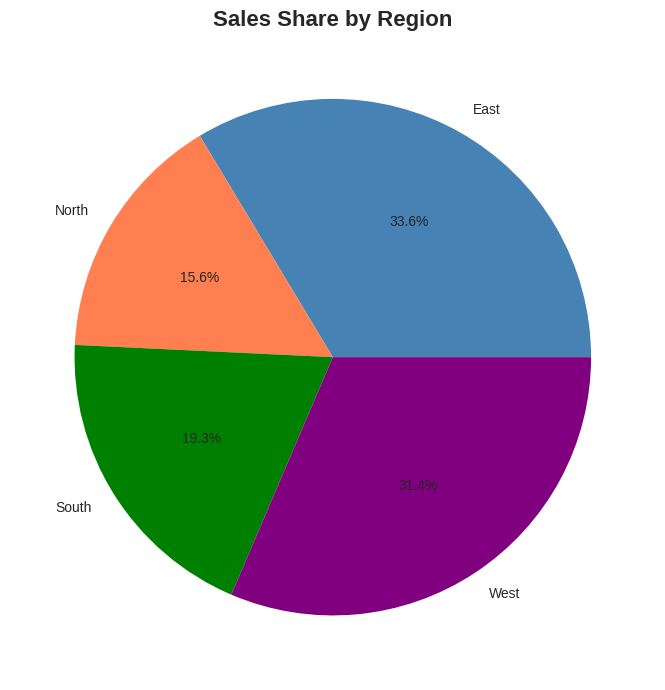

In [14]:
df.groupby('Region')['Sales'].sum().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7),
    colors=['steelblue','coral','green','purple']
)
plt.title('Sales Share by Region', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

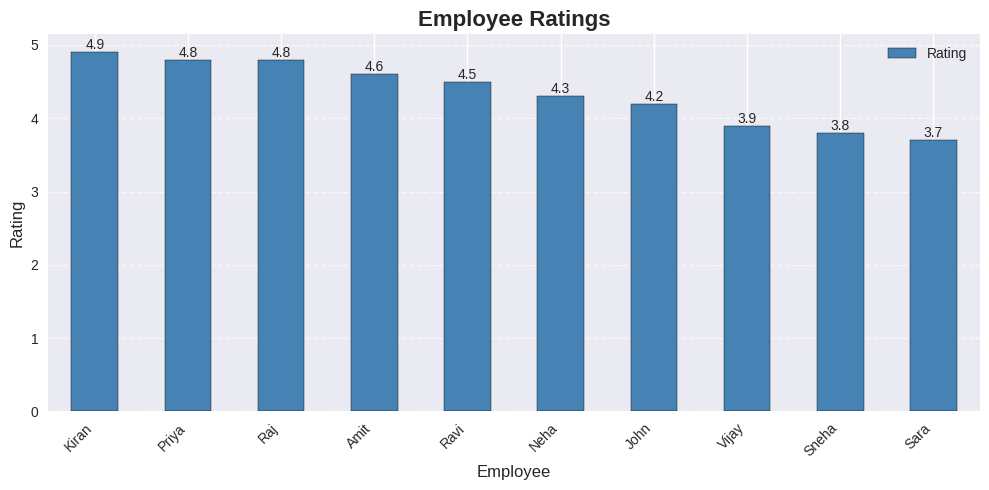

In [15]:
ax = df.sort_values('Rating', ascending=False).plot(
    kind='bar',
    x='Employee',
    y='Rating',
    color='steelblue',
    figsize=(10,5),
    edgecolor='black'
)
for p in ax.patches:
    ax.annotate(
        str(round(p.get_height(), 1)),
        xy=(p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.title('Employee Ratings', fontsize=16, fontweight='bold')
plt.xlabel('Employee', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()